In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

print("torch       :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available())

torch       : 2.11.0+cu128
CUDA avail. : True


In [2]:
SEED         = 42
IMG_SIZE     = 128      # resize every scan to 128 x 128
IMG_CHANNELS = 1        # grayscale (ultrasound)
BATCH_SIZE   = 32
EPOCHS       = 30       # assignment requires a minimum of 20
LR           = 1e-3
DROPOUT_CONV = 0.30     # dropout inside the convolutional trunk
DROPOUT_FC   = 0.50     # heavier dropout in the dense head
FIG_DIR      = "figures"

os.makedirs(FIG_DIR, exist_ok=True)


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN costs a little speed but makes results repeatable
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]   = 110
plt.rcParams["savefig.dpi"]  = 200
plt.rcParams["savefig.bbox"] = "tight"

Training device : cuda
GPU             : Tesla T4


In [3]:
def locate_busi() -> Path:

    def is_busi_root(p: Path) -> bool:
        return p.is_dir() and all((p / c).is_dir() for c in ("benign", "malignant"))

    # 1) Explicit override
    env_root = os.environ.get("BUSI_ROOT")
    if env_root:
        p = Path(env_root)
        if is_busi_root(p):
            return p
        # Allow pointing at the parent of Dataset_BUSI_with_GT
        for sub in p.rglob("*"):
            if is_busi_root(sub):
                return sub
        raise FileNotFoundError(f"BUSI_ROOT={env_root} does not contain benign/ and malignant/.")

    # 2) kagglehub (Colab / any machine with internet + Kaggle credentials)
    try:
        import kagglehub
        dl = Path(kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset"))
        for cand in [dl, *dl.rglob("*")]:
            if is_busi_root(cand):
                return cand
    except Exception as exc:                       # offline, no creds, or package missing
        print(f"[info] kagglehub unavailable ({type(exc).__name__}): {exc}")

    # 3) Common local fallbacks
    for cand in [Path("Dataset_BUSI_with_GT"), Path("data/Dataset_BUSI_with_GT"), Path("BUSI")]:
        if is_busi_root(cand):
            return cand

    raise FileNotFoundError(
        "Could not locate BUSI.\n"
        "Fix: download 'aryashah2k/breast-ultrasound-images-dataset' from Kaggle, unzip it, "
        "then set BUSI_ROOT to the folder containing benign/ and malignant/."
    )


DATA_ROOT = locate_busi()
print("Dataset root:", DATA_ROOT.resolve())
print("Subfolders  :", sorted(d.name for d in DATA_ROOT.iterdir() if d.is_dir()))

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset root: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Subfolders  : ['benign', 'malignant', 'normal']


In [4]:
# benign = 0 (negative), malignant = 1 (positive) -> sigmoid output reads as P(malignant)
CLASS_NAMES = ["benign", "malignant"]
CLASS_TO_IDX = {"benign": 0, "malignant": 1}

records = []
for class_name, label in CLASS_TO_IDX.items():
    class_dir = DATA_ROOT / class_name
    for img_path in sorted(class_dir.glob("*.png")):
        # CRITICAL: skip segmentation masks -- these are annotations, not inputs
        if "_mask" in img_path.stem.lower():
            continue
        records.append({"path": str(img_path), "label": label, "class": class_name})

index_df = pd.DataFrame(records)

# --- Integrity check on the assembled index --------------------------------
n_masks_skipped = sum(
    1 for c in CLASS_NAMES for p in (DATA_ROOT / c).glob("*.png") if "_mask" in p.stem.lower()
)

print("=" * 58)
print("DATASET INDEX")
print("=" * 58)
print(f"  Usable scans indexed   : {len(index_df)}")
print(f"  Mask files excluded    : {n_masks_skipped}")
if index_df.empty:
    raise RuntimeError("[FATAL] No images indexed -- check DATA_ROOT.")
else:
    print("  [OK] Index is non-empty.")

print("\n  Class distribution:")
for c in CLASS_NAMES:
    n = int((index_df["class"] == c).sum())
    print(f"    {c:<10} {n:>4}  ({n / len(index_df) * 100:.1f}%)")

imb = index_df["label"].value_counts()
print(f"\n  Imbalance ratio: {imb.max() / imb.min():.2f}:1 "
      "-> stratified splitting + weighted sampling will be used.")
index_df.head()

DATASET INDEX
  Usable scans indexed   : 647
  Mask files excluded    : 665
  [OK] Index is non-empty.

  Class distribution:
    benign      437  (67.5%)
    malignant   210  (32.5%)

  Imbalance ratio: 2.08:1 -> stratified splitting + weighted sampling will be used.


,path,label,class
0,/kaggle/input/breast-ultrasound-images-dataset...,0,benign
1,/kaggle/input/breast-ultrasound-images-dataset...,0,benign
2,/kaggle/input/breast-ultrasound-images-dataset...,0,benign
3,/kaggle/input/breast-ultrasound-images-dataset...,0,benign
4,/kaggle/input/breast-ultrasound-images-dataset...,0,benign


In [5]:
labels = index_df["label"].values

# Stage 1: carve off 70% train, 30% temporary holdout
train_idx, temp_idx = train_test_split(
    np.arange(len(index_df)),
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

# Stage 2: split the 30% holdout evenly -> 15% validation, 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=labels[temp_idx],
)

split_summary = []
for name, idx in [("Train", train_idx), ("Validation", val_idx), ("Test", test_idx)]:
    sub = index_df.iloc[idx]
    split_summary.append({
        "Split":     name,
        "N":         len(sub),
        "% of data": round(len(sub) / len(index_df) * 100, 1),
        "Benign":    int((sub["label"] == 0).sum()),
        "Malignant": int((sub["label"] == 1).sum()),
        "% Malignant": round((sub["label"] == 1).mean() * 100, 1),
    })

split_df = pd.DataFrame(split_summary)
print("Stratification check -- the malignant proportion should be near-identical across splits:\n")
split_df

Stratification check -- the malignant proportion should be near-identical across splits:



,Split,N,% of data,Benign,Malignant,% Malignant
0,Train,452,69.9,305,147,32.5
1,Validation,97,15.0,66,31,32.0
2,Test,98,15.1,66,32,32.7


In [6]:
# --- Verify the splits are disjoint (no leakage between partitions) --------
sets = [set(train_idx), set(val_idx), set(test_idx)]
overlap = (sets[0] & sets[1]) | (sets[0] & sets[2]) | (sets[1] & sets[2])
if overlap:
    print(f"[FATAL] {len(overlap)} sample(s) appear in more than one split!")
else:
    print(f"[OK] Splits are disjoint and cover all {len(train_idx)+len(val_idx)+len(test_idx)} samples.")

[OK] Splits are disjoint and cover all 647 samples.


In [7]:
class BUSIDataset(Dataset):
    """Breast Ultrasound Images dataset.

    Parameters
    ----------
    frame : pd.DataFrame
        Full index with 'path' and 'label' columns.
    indices : array-like
        Row positions belonging to this split.
    transform : callable, optional
        torchvision transform pipeline applied to each PIL image.
    """

    def __init__(self, frame: pd.DataFrame, indices, transform=None):
        self.frame     = frame.iloc[indices].reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]

        # 'L' = 8-bit grayscale. Ultrasound carries no meaningful colour information.
        image = Image.open(row["path"]).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        # BCELoss expects a float target shaped like the model output
        label = torch.tensor([row["label"]], dtype=torch.float32)
        return image, label

In [8]:
# Pass 1: load the training images with resize + ToTensor ONLY (no augmentation,
# no normalisation) purely to measure the pixel distribution.
stats_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),                      # scales pixels to [0, 1]
])

stats_ds = BUSIDataset(index_df, train_idx, transform=stats_transform)
stats_loader = DataLoader(stats_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Accumulate sum and sum-of-squares to get mean/std in a single streaming pass
n_pixels = 0.0
px_sum   = 0.0
px_sqsum = 0.0

for imgs, _ in stats_loader:
    b = imgs.size(0)
    imgs = imgs.view(b, IMG_CHANNELS, -1)
    n_pixels += b * imgs.size(2)
    px_sum   += imgs.sum(dim=[0, 2]).item()
    px_sqsum += (imgs ** 2).sum(dim=[0, 2]).item()

DATA_MEAN = px_sum / n_pixels
DATA_STD  = float(np.sqrt(px_sqsum / n_pixels - DATA_MEAN ** 2))

print(f"Training-split pixel statistics ({len(stats_ds)} images):")
print(f"  mean = {DATA_MEAN:.4f}")
print(f"  std  = {DATA_STD:.4f}")
print("\nThese values normalise all three splits (train/val/test) identically.")

Training-split pixel statistics (452 images):
  mean = 0.3318
  std  = 0.2177

These values normalise all three splits (train/val/test) identically.


In [9]:
FILL_VALUE = int(DATA_MEAN * 255)

# --- Training pipeline: augmentation + normalisation -----------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=12, fill=FILL_VALUE),
    T.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1), fill=FILL_VALUE),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[DATA_MEAN], std=[DATA_STD]),
])

# --- Evaluation pipeline: deterministic, NO augmentation -------------------
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[DATA_MEAN], std=[DATA_STD]),
])

train_ds = BUSIDataset(index_df, train_idx, transform=train_transform)
val_ds   = BUSIDataset(index_df, val_idx,   transform=eval_transform)
test_ds  = BUSIDataset(index_df, test_idx,  transform=eval_transform)

print(f"Train : {len(train_ds):>4} images  (augmented)")
print(f"Val   : {len(val_ds):>4} images  (deterministic)")
print(f"Test  : {len(test_ds):>4} images  (deterministic)")

Train :  452 images  (augmented)
Val   :   97 images  (deterministic)
Test  :   98 images  (deterministic)


In [10]:
train_labels = index_df.iloc[train_idx]["label"].values
class_counts = np.bincount(train_labels, minlength=2)
class_weights = 1.0 / class_counts                 # rarer class -> larger weight
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0

# drop_last=True guards against a final batch of size 1, which would crash
# BatchNorm in training mode (it cannot compute variance over a single sample).
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

print(f"Train class counts : benign={class_counts[0]}, malignant={class_counts[1]}")
print(f"Sampling weights   : benign={class_weights[0]:.5f}, malignant={class_weights[1]:.5f}")
print(f"\nBatches per epoch  : {len(train_loader)} train | {len(val_loader)} val | {len(test_loader)} test")

Train class counts : benign=305, malignant=147
Sampling weights   : benign=0.00328, malignant=0.00680

Batches per epoch  : 14 train | 4 val | 4 test


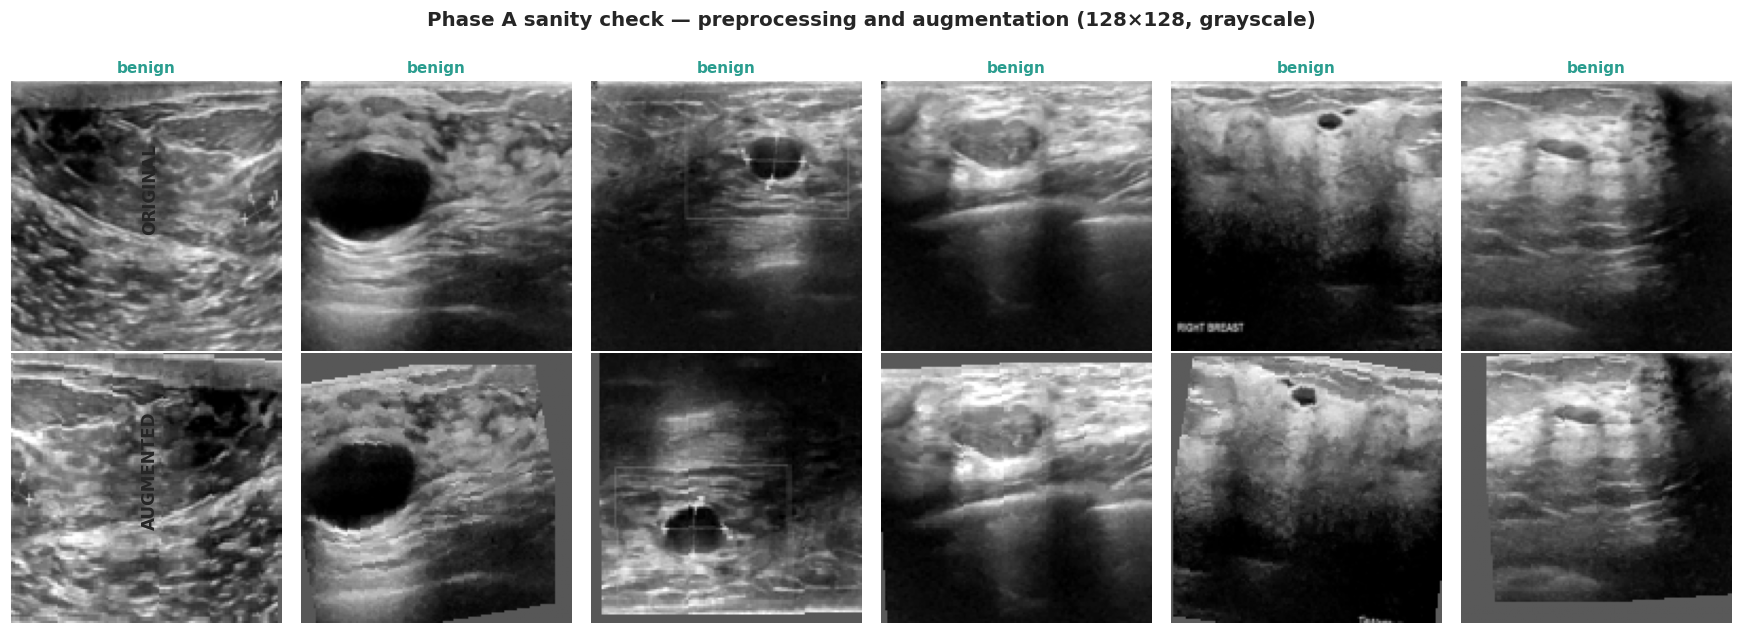

In [11]:
def denormalise(t: torch.Tensor) -> np.ndarray:
    """Undo Normalize() so a tensor can be displayed as an image."""
    return np.clip(t.squeeze().cpu().numpy() * DATA_STD + DATA_MEAN, 0, 1)


# --- Row 1: raw scans | Row 2: the same scans after augmentation -----------
fig, axes = plt.subplots(2, 6, figsize=(16, 5.8))

sample_positions = [0, 1, 2, len(train_ds) - 3, len(train_ds) - 2, len(train_ds) - 1]
raw_ds = BUSIDataset(index_df, train_idx, transform=eval_transform)

for col, pos in enumerate(sample_positions):
    img_raw, lab = raw_ds[pos]
    axes[0, col].imshow(denormalise(img_raw), cmap="gray")
    axes[0, col].set_title(f"{CLASS_NAMES[int(lab.item())]}", fontsize=10,
                           color="#d00000" if lab.item() == 1 else "#2a9d8f",
                           fontweight="bold")
    axes[0, col].axis("off")

    img_aug, _ = train_ds[pos]        # same index, augmented pipeline
    axes[1, col].imshow(denormalise(img_aug), cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11, fontweight="bold")
fig.text(0.085, 0.72, "ORIGINAL",  rotation=90, va="center", fontweight="bold", fontsize=11)
fig.text(0.085, 0.28, "AUGMENTED", rotation=90, va="center", fontweight="bold", fontsize=11)
fig.suptitle("Phase A sanity check — preprocessing and augmentation "
             f"({IMG_SIZE}×{IMG_SIZE}, grayscale)",
             fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_data_samples.png"))
plt.show()

In [12]:

val_imgs, val_labels = next(iter(val_loader))
print("VALIDATION batch (deterministic pipeline)")
print(f"  Image tensor : {tuple(val_imgs.shape)}  (N, C, H, W)")
print(f"  Label tensor : {tuple(val_labels.shape)}  dtype={val_labels.dtype}")
print(f"  Pixel range  : [{val_imgs.min():.2f}, {val_imgs.max():.2f}]")
print(f"  Mean / std   : {val_imgs.mean():+.3f} / {val_imgs.std():.3f}   <- expect ~0 / ~1")

train_imgs, train_labels = next(iter(train_loader))
print("\nTRAINING batch (augmented pipeline)")
print(f"  Image tensor : {tuple(train_imgs.shape)}")
print(f"  Mean / std   : {train_imgs.mean():+.3f} / {train_imgs.std():.3f}   "
      "<- intentionally shifted by augmentation")
print(f"  Malignant    : {int(train_labels.sum().item())}/{len(train_labels)} "
      "(weighted sampler targets ~50%)")

assert val_imgs.shape[1:] == (IMG_CHANNELS, IMG_SIZE, IMG_SIZE), "Unexpected image shape"
print("\n[OK] Tensor shapes and normalisation verified.")

VALIDATION batch (deterministic pipeline)
  Image tensor : (32, 1, 128, 128)  (N, C, H, W)
  Label tensor : (32, 1)  dtype=torch.float32
  Pixel range  : [-1.52, 3.07]
  Mean / std   : -0.011 / 1.009   <- expect ~0 / ~1

TRAINING batch (augmented pipeline)
  Image tensor : (32, 1, 128, 128)
  Mean / std   : -0.036 / 0.940   <- intentionally shifted by augmentation
  Malignant    : 13/32 (weighted sampler targets ~50%)

[OK] Tensor shapes and normalisation verified.


In [13]:
class CancerCNN(nn.Module):
    """Custom CNN for binary classification of breast ultrasound scans."""

    def __init__(self, in_channels=IMG_CHANNELS, p_conv=DROPOUT_CONV, p_fc=DROPOUT_FC):
        super().__init__()

        def conv_block(cin, cout, dropout=True):
            """Conv -> BatchNorm -> ReLU -> MaxPool (-> optional channel dropout)."""
            layers = [
                nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),          # stabilises training, allows a higher LR
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2),   # halve spatial dimensions
            ]
            if dropout:
                layers.append(nn.Dropout2d(p_conv))
            return nn.Sequential(*layers)

        # --- Feature extraction trunk: 4 convolutional blocks --------------
        self.block1 = conv_block(in_channels, 32,  dropout=False)  # 128 -> 64
        self.block2 = conv_block(32,  64)                          #  64 -> 32
        self.block3 = conv_block(64,  128)                         #  32 -> 16
        self.block4 = conv_block(128, 256)                         #  16 -> 8

        # Fixes the flattened size at 256*4*4 independently of input resolution
        self.pool = nn.AdaptiveAvgPool2d(4)

        # --- Classification head ------------------------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_fc),

            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p_fc),

            nn.Linear(64, 1),
            nn.Sigmoid(),          # single output node -> P(malignant)
        )

        self._init_weights()

    def _init_weights(self):
        """He initialisation for ReLU networks -- keeps activation variance stable with depth."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)                   # Grad-CAM hooks this block's output in Phase C
        x = self.pool(x)
        return self.classifier(x)


set_seed(SEED)
model = CancerCNN().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 1,454,177
Trainable parameters : 1,454,177


In [14]:
# --- Shape trace: verify the tensor dimensions at every stage --------------
model.eval()
with torch.no_grad():
    x = torch.randn(2, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
    print(f"{'Input':<26} {tuple(x.shape)}")
    for name in ["block1", "block2", "block3", "block4"]:
        x = getattr(model, name)(x)
        print(f"{name:<26} {tuple(x.shape)}")
    x = model.pool(x)
    print(f"{'AdaptiveAvgPool(4)':<26} {tuple(x.shape)}")
    out = model.classifier(x)
    print(f"{'Classifier output':<26} {tuple(out.shape)}   range=[{out.min():.3f}, {out.max():.3f}]")

assert out.shape == (2, 1), "Output must be a single node per sample"
assert 0.0 <= out.min().item() and out.max().item() <= 1.0, "Sigmoid output must lie in [0, 1]"
print("\n[OK] Architecture verified: single sigmoid output in [0, 1].")

Input                      (2, 1, 128, 128)
block1                     (2, 32, 64, 64)
block2                     (2, 64, 32, 32)
block3                     (2, 128, 16, 16)
block4                     (2, 256, 8, 8)
AdaptiveAvgPool(4)         (2, 256, 4, 4)
Classifier output          (2, 1)   range=[0.619, 0.626]

[OK] Architecture verified: single sigmoid output in [0, 1].


In [15]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4,
)

print(f"Loss      : {criterion.__class__.__name__}")
print(f"Optimiser : Adam (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)")
print(f"Epochs    : {EPOCHS}")

Loss      : BCELoss
Optimiser : Adam (lr=0.001, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)
Epochs    : 30


In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one epoch. Passing an optimizer puts the model in training mode.

    Returns (mean_loss, accuracy).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    # Gradients are only needed when training
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)                 # (N, 1) probabilities
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = (outputs >= 0.5).float()        # 0.5 decision threshold
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return running_loss / total, correct / total

In [17]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

best_val_loss  = float("inf")
best_epoch     = -1
best_state     = None
CHECKPOINT     = "best_cancer_cnn.pt"

print(f"Training on {DEVICE} for {EPOCHS} epochs\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} {'Train Acc':>9} | "
      f"{'Val Loss':>9} {'Val Acc':>8} | {'LR':>8} | {'Time':>6}")
print("-" * 74)

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)

    scheduler.step(val_loss)                       # LR decay on plateau
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # Checkpoint the best-generalising weights
    flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, CHECKPOINT)
        flag = "  <- best"

    print(f"{epoch:>5} | {train_loss:>10.4f} {train_acc:>9.4f} | "
          f"{val_loss:>9.4f} {val_acc:>8.4f} | {current_lr:>8.1e} | "
          f"{time.time() - t0:>5.1f}s{flag}")

print("-" * 74)
print(f"Training finished in {(time.time() - t_start) / 60:.1f} min")
print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")

Training on cuda for 30 epochs

Epoch | Train Loss Train Acc |  Val Loss  Val Acc |       LR |   Time
--------------------------------------------------------------------------
    1 |     0.9505    0.5737 |    0.8833   0.3196 |  1.0e-03 |   6.2s  <- best
    2 |     0.8907    0.5759 |    0.6621   0.6082 |  1.0e-03 |   4.0s  <- best
    3 |     0.8129    0.6183 |    0.9709   0.3505 |  1.0e-03 |   4.9s
    4 |     0.7472    0.6027 |    0.8280   0.4536 |  1.0e-03 |   4.5s
    5 |     0.7041    0.6183 |    0.6907   0.5361 |  1.0e-03 |   4.1s
    6 |     0.6635    0.6540 |    0.6401   0.6392 |  1.0e-03 |   5.2s  <- best
    7 |     0.6964    0.6205 |    0.6129   0.6289 |  1.0e-03 |   4.0s  <- best
    8 |     0.6974    0.6295 |    0.6347   0.6186 |  1.0e-03 |   4.2s
    9 |     0.6608    0.6295 |    0.6251   0.6495 |  1.0e-03 |   5.3s
   10 |     0.6231    0.6875 |    0.5912   0.6804 |  1.0e-03 |   5.6s  <- best
   11 |     0.6112    0.6674 |    0.5729   0.7320 |  1.0e-03 |   4.3s  <- best

In [18]:
# Restore the best checkpoint so all Phase C evaluation uses the best-generalising model
model.load_state_dict(best_state)
model.to(DEVICE).eval()
print(f"Restored weights from epoch {best_epoch} (val_loss={best_val_loss:.4f}).")

Restored weights from epoch 26 (val_loss=0.4945).


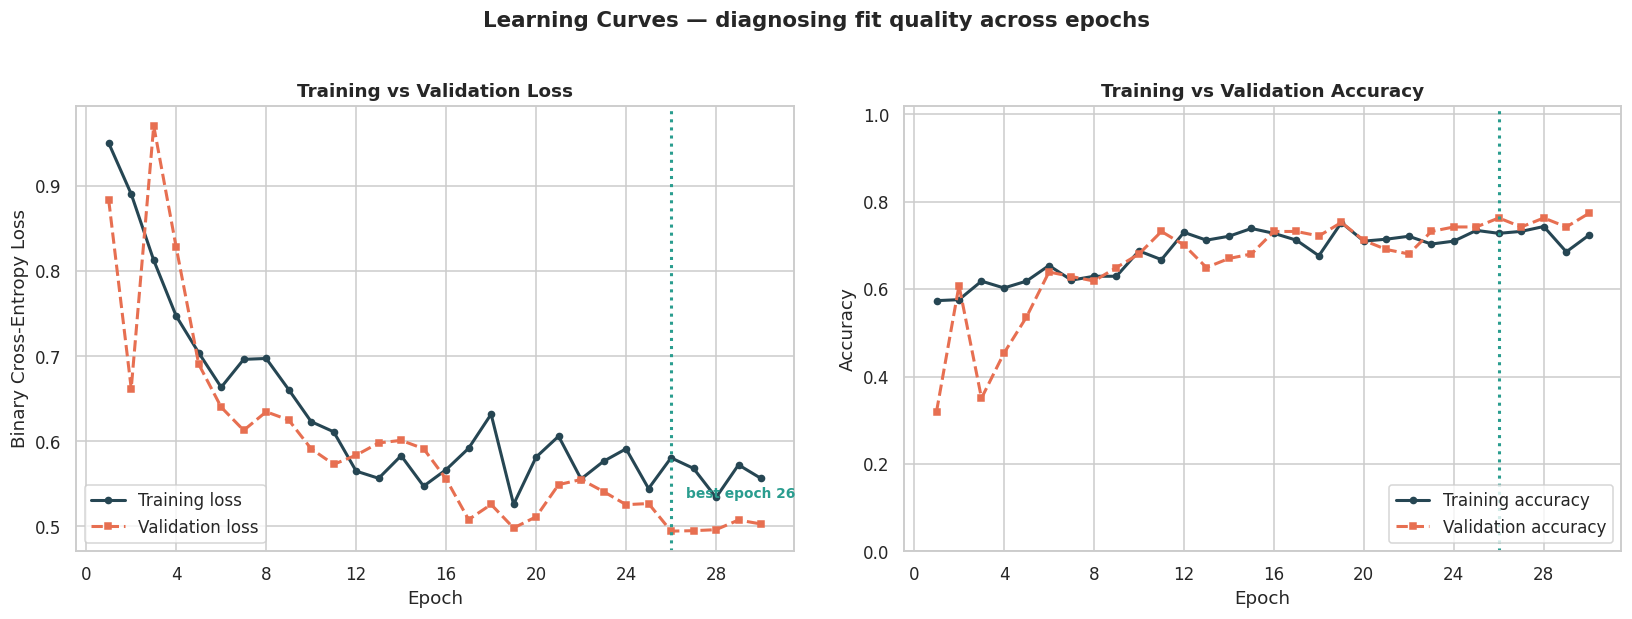

Final training accuracy   : 0.7232
Final validation accuracy : 0.7732
Generalisation gap        : -0.0500

-> Curves are tightly coupled: regularisation is doing its job (possibly slightly underfit -- more capacity or epochs may help).


In [19]:
from matplotlib.ticker import MaxNLocator

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Panel 1: Loss ---------------------------------------------------------
axes[0].plot(epochs_range, history["train_loss"], "o-", color="#264653",
             linewidth=2, markersize=4, label="Training loss")
axes[0].plot(epochs_range, history["val_loss"], "s--", color="#e76f51",
             linewidth=2, markersize=4, label="Validation loss")
axes[0].axvline(best_epoch, color="#2a9d8f", linestyle=":", linewidth=2)
axes[0].annotate(f"best epoch {best_epoch}",
                 xy=(best_epoch, best_val_loss), xytext=(10, 22),
                 textcoords="offset points", fontsize=9,
                 color="#2a9d8f", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].set_title("Training vs Validation Loss", fontweight="bold")
axes[0].legend()

# --- Panel 2: Accuracy -----------------------------------------------------
axes[1].plot(epochs_range, history["train_acc"], "o-", color="#264653",
             linewidth=2, markersize=4, label="Training accuracy")
axes[1].plot(epochs_range, history["val_acc"], "s--", color="#e76f51",
             linewidth=2, markersize=4, label="Validation accuracy")
axes[1].axvline(best_epoch, color="#2a9d8f", linestyle=":", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy", fontweight="bold")
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower right")

# Epochs are discrete -- suppress fractional tick labels like "1.5"
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("Learning Curves — diagnosing fit quality across epochs",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_learning_curves.png"))
plt.show()

# --- Quantify the overfitting gap -----------------------------------------
final_gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"Final training accuracy   : {history['train_acc'][-1]:.4f}")
print(f"Final validation accuracy : {history['val_acc'][-1]:.4f}")
print(f"Generalisation gap        : {final_gap:+.4f}")
if final_gap > 0.15:
    print("\n-> Sizeable gap: the model is overfitting. Stronger augmentation, "
          "higher dropout, or earlier stopping would help.")
elif final_gap < 0.02:
    print("\n-> Curves are tightly coupled: regularisation is doing its job "
          "(possibly slightly underfit -- more capacity or epochs may help).")
else:
    print("\n-> Modest gap: a healthy fit for a dataset of this size.")

In [20]:
# --- Collect predictions on the held-out test set --------------------------
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for images, labels in test_loader:
        probs = model(images.to(DEVICE)).cpu().numpy().ravel()
        y_prob.extend(probs)
        y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true, dtype=int)
y_prob = np.array(y_prob, dtype=float)
y_pred = (y_prob >= 0.5).astype(int)      # malignant = 1 = positive class

test_metrics = {
    "Accuracy":  accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall":    recall_score(y_true, y_pred, zero_division=0),
    "F1-Score":  f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_true, y_prob),
}

print("=" * 56)
print("TEST-SET PERFORMANCE  (positive class = malignant)")
print("=" * 56)
for k, v in test_metrics.items():
    print(f"  {k:<12} {v:.4f}")
print("=" * 56)
print("\nPer-class breakdown:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

TEST-SET PERFORMANCE  (positive class = malignant)
  Accuracy     0.7551
  Precision    0.6250
  Recall       0.6250
  F1-Score     0.6250
  ROC-AUC      0.8163

Per-class breakdown:

              precision    recall  f1-score   support

      benign     0.8182    0.8182    0.8182        66
   malignant     0.6250    0.6250    0.6250        32

    accuracy                         0.7551        98
   macro avg     0.7216    0.7216    0.7216        98
weighted avg     0.7551    0.7551    0.7551        98



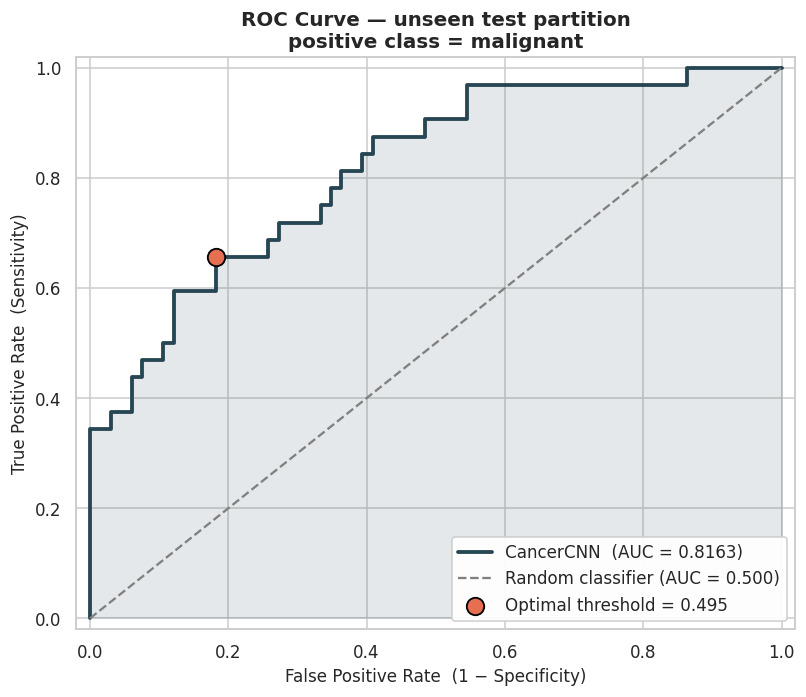

AUC = 0.8163
Youden-optimal threshold = 0.495 (vs the default 0.5) -> sensitivity 0.656, specificity 0.818


In [21]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.plot(fpr, tpr, color="#264653", linewidth=2.5,
        label=f"CancerCNN  (AUC = {roc_auc:.4f})")
ax.fill_between(fpr, tpr, alpha=0.12, color="#264653")
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1.5,
        label="Random classifier (AUC = 0.500)")

# Youden's J: the threshold maximising (sensitivity + specificity - 1)
j_scores  = tpr - fpr
j_best    = int(np.argmax(j_scores))
opt_thresh = thresholds[j_best]
ax.scatter(fpr[j_best], tpr[j_best], s=130, color="#e76f51", zorder=5,
           edgecolor="black", linewidth=1.2,
           label=f"Optimal threshold = {opt_thresh:.3f}")

ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate  (Sensitivity)", fontsize=11)
ax.set_title("ROC Curve — unseen test partition\n"
             "positive class = malignant", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", framealpha=0.95)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_roc_curve.png"))
plt.show()

print(f"AUC = {roc_auc:.4f}")
print(f"Youden-optimal threshold = {opt_thresh:.3f} "
      f"(vs the default 0.5) -> sensitivity {tpr[j_best]:.3f}, "
      f"specificity {1 - fpr[j_best]:.3f}")

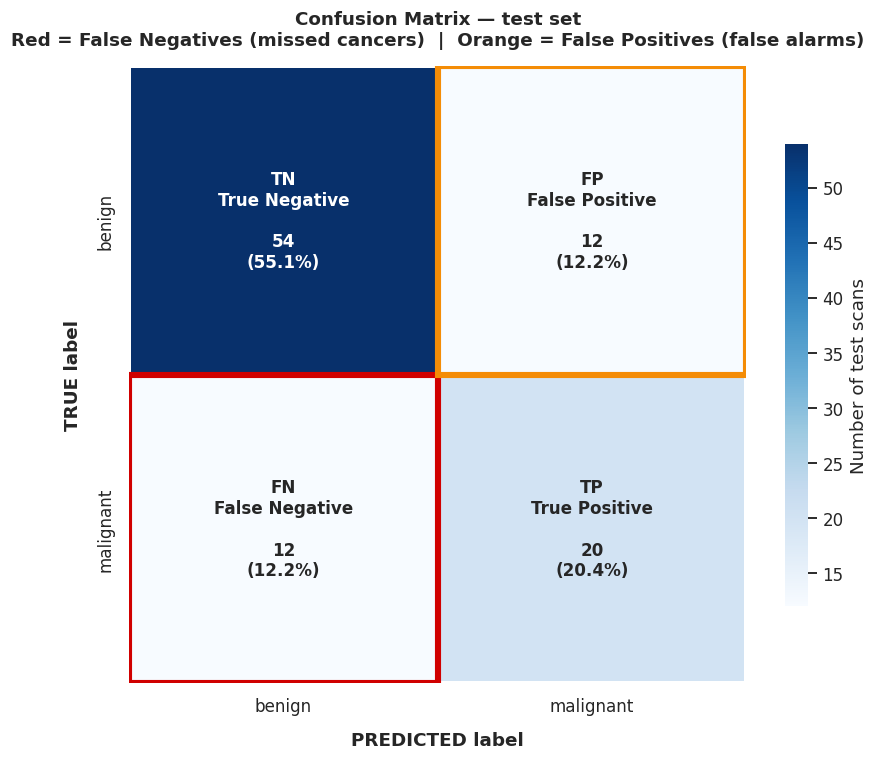

Sensitivity (malignant recall) : 0.6250   -> 12 cancer(s) missed
Specificity (benign recall)    : 0.8182   -> 12 false alarm(s)


In [22]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP = cm[0, 0], cm[0, 1]     # true benign
FN, TP = cm[1, 0], cm[1, 1]     # true malignant

quadrant_labels = np.array([["TN\nTrue Negative",  "FP\nFalse Positive"],
                            ["FN\nFalse Negative", "TP\nTrue Positive"]])
total = cm.sum()
annot = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i, j] = f"{quadrant_labels[i, j]}\n\n{cm[i, j]}\n({cm[i, j] / total * 100:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 6.8))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", square=True,
            linewidths=2.5, linecolor="white",
            cbar_kws={"label": "Number of test scans", "shrink": 0.75},
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)

# Outline the two error quadrants
for (row, col, colour) in [(1, 0, "#d00000"),    # FN -> red (missed cancer)
                           (0, 1, "#f48c06")]:   # FP -> orange (false alarm)
    ax.add_patch(patches.Rectangle((col, row), 1, 1, fill=False,
                                   edgecolor=colour, linewidth=4, zorder=10))

ax.set_xlabel("PREDICTED label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("TRUE label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Confusion Matrix — test set\n"
             "Red = False Negatives (missed cancers)  |  "
             "Orange = False Positives (false alarms)",
             fontsize=12, fontweight="bold", pad=14)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_confusion_matrix.png"))
plt.show()

sensitivity = TP / (TP + FN) if (TP + FN) else 0.0
specificity = TN / (TN + FP) if (TN + FP) else 0.0
print(f"Sensitivity (malignant recall) : {sensitivity:.4f}   -> {FN} cancer(s) missed")
print(f"Specificity (benign recall)    : {specificity:.4f}   -> {FP} false alarm(s)")

In [23]:
class GradCAM:
    """Grad-CAM for a CNN, implemented with forward/backward hooks.

    Registers on a target convolutional layer, captures its activations on the
    forward pass and the gradients flowing back into it, then combines them into
    a class-discriminative localisation map.
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.activations  = None
        self.gradients    = None
        self.handles = [
            target_layer.register_forward_hook(self._save_activation),
            target_layer.register_full_backward_hook(self._save_gradient),
        ]

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor: torch.Tensor) -> np.ndarray:
        """Return a (H, W) heatmap normalised to [0, 1] for a single image."""
        self.model.eval()
        self.model.zero_grad()

        score = self.model(input_tensor)        # P(malignant), shape (1, 1)
        score.backward()                        # gradients wrt the malignancy score

        # Global-average-pool the gradients -> one importance weight per channel
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)     # (1, C, 1, 1)

        # Weighted combination of activation maps, then keep positive influence only
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))

        # Upsample to input resolution and normalise to [0, 1] for display
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

    def close(self):
        for h in self.handles:
            h.remove()


# Hook the LAST convolutional block: deepest semantics that still retain spatial layout
target_layer = model.block4[0]
gradcam = GradCAM(model, target_layer)
print(f"Grad-CAM attached to: block4 Conv2d "
      f"({target_layer.in_channels} -> {target_layer.out_channels} channels)")

Grad-CAM attached to: block4 Conv2d (128 -> 256 channels)


In [24]:
# --- Choose informative examples: correct + incorrect, both classes --------
correct_mal = np.where((y_true == 1) & (y_pred == 1))[0]
correct_ben = np.where((y_true == 0) & (y_pred == 0))[0]
mistakes    = np.where(y_true != y_pred)[0]

selected = []
if len(correct_mal): selected.append((correct_mal[0], "Correct: malignant"))
if len(correct_ben): selected.append((correct_ben[0], "Correct: benign"))
if len(mistakes):    selected.append((mistakes[0],    "MISCLASSIFIED"))
if len(correct_mal) > 1: selected.append((correct_mal[1], "Correct: malignant"))

selected = selected[:4]
while len(selected) < 2:                       # guarantee the required minimum of 2
    selected.append((len(selected), "Test sample"))

print(f"Visualising {len(selected)} test scans:")
for idx, tag in selected:
    print(f"  #{idx:<3} {tag:<20} true={CLASS_NAMES[y_true[idx]]:<10} "
          f"pred={CLASS_NAMES[y_pred[idx]]:<10} P(malignant)={y_prob[idx]:.3f}")

Visualising 4 test scans:
  #21  Correct: malignant   true=malignant  pred=malignant  P(malignant)=0.653
  #0   Correct: benign      true=benign     pred=benign     P(malignant)=0.297
  #4   MISCLASSIFIED        true=benign     pred=malignant  P(malignant)=0.574
  #23  Correct: malignant   true=malignant  pred=malignant  P(malignant)=0.741


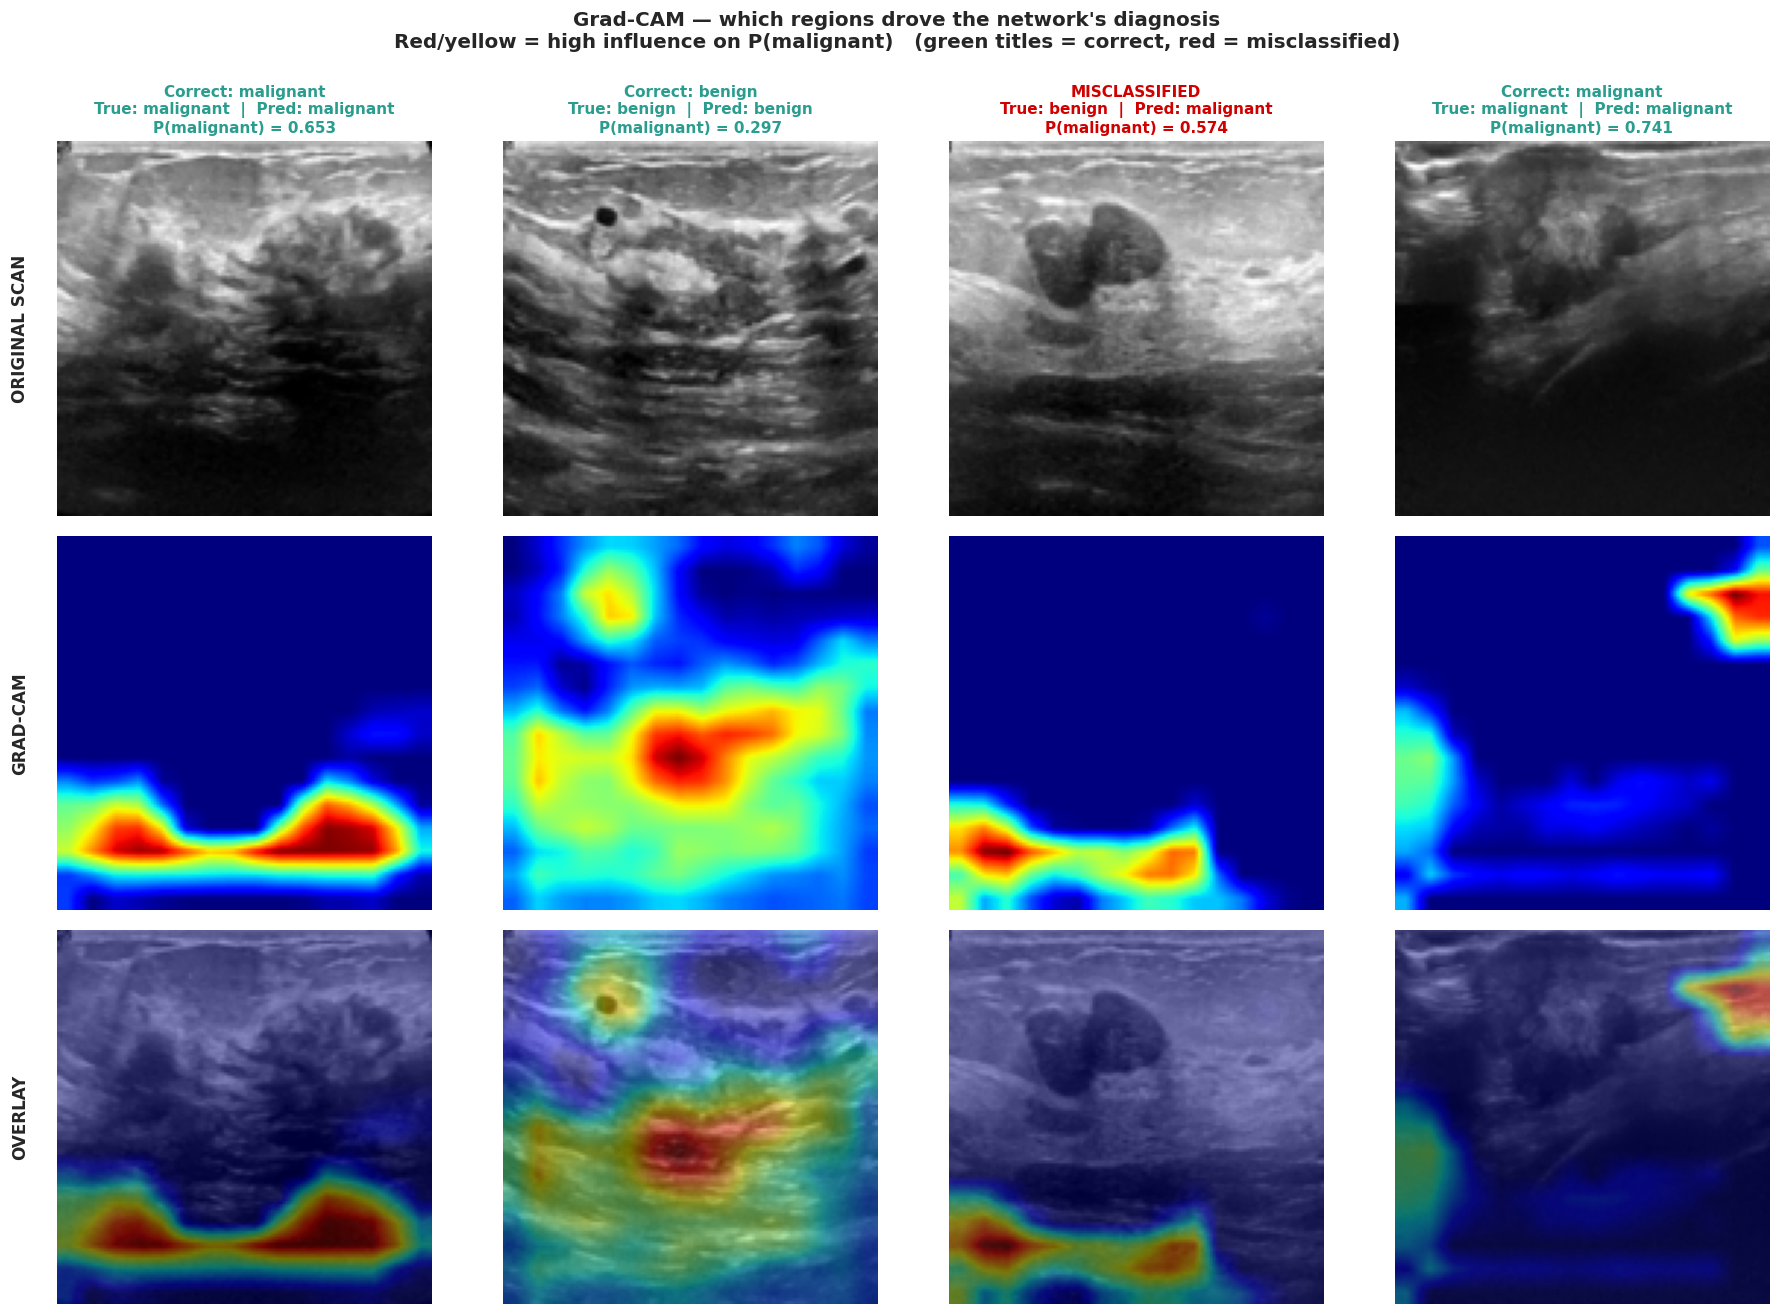

Grad-CAM hooks removed.


In [25]:
fig, axes = plt.subplots(3, len(selected), figsize=(4.2 * len(selected), 12))
axes = axes.reshape(3, -1)

for col, (idx, tag) in enumerate(selected):
    image, label = test_ds[idx]
    input_tensor = image.unsqueeze(0).to(DEVICE)   # add batch dimension

    heatmap = gradcam(input_tensor)
    original = denormalise(image)

    correct = y_true[idx] == y_pred[idx]
    edge = "#2a9d8f" if correct else "#d00000"

    # Row 1: the original scan
    axes[0, col].imshow(original, cmap="gray")
    axes[0, col].set_title(
        f"{tag}\nTrue: {CLASS_NAMES[y_true[idx]]}  |  Pred: {CLASS_NAMES[y_pred[idx]]}\n"
        f"P(malignant) = {y_prob[idx]:.3f}",
        fontsize=10, fontweight="bold", color=edge)

    # Row 2: the raw Grad-CAM heatmap
    axes[1, col].imshow(heatmap, cmap="jet")

    # Row 3: heatmap overlaid on the scan
    axes[2, col].imshow(original, cmap="gray")
    axes[2, col].imshow(heatmap, cmap="jet", alpha=0.45)

    for row in range(3):
        axes[row, col].axis("off")
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(edge)

for row, lbl in enumerate(["ORIGINAL SCAN", "GRAD-CAM", "OVERLAY"]):
    axes[row, 0].text(-0.10, 0.5, lbl, rotation=90, va="center", ha="center",
                      transform=axes[row, 0].transAxes,
                      fontsize=11, fontweight="bold")

fig.suptitle("Grad-CAM — which regions drove the network's diagnosis\n"
             "Red/yellow = high influence on P(malignant)   "
             "(green titles = correct, red = misclassified)",
             fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_gradcam.png"))
plt.show()

gradcam.close()      # always remove hooks to avoid leaking them into later cells
print("Grad-CAM hooks removed.")

In [26]:
# --- Final artefact manifest and results summary ---------------------------
print("Saved figures:\n")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f:<32} {os.path.getsize(os.path.join(FIG_DIR, f)) / 1024:>7.1f} KB")

print("\n" + "=" * 56)
print("FINAL TEST-SET RESULTS")
print("=" * 56)
for k, v in test_metrics.items():
    print(f"  {k:<12} {v:.4f}")
print("-" * 56)
print(f"  Best epoch           : {best_epoch} / {EPOCHS}")
print(f"  Best validation loss : {best_val_loss:.4f}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Training images      : {len(train_ds)} (augmented)")
print("=" * 56)

Saved figures:

  01_data_samples.png                387.8 KB
  02_learning_curves.png             219.6 KB
  03_roc_curve.png                   119.9 KB
  04_confusion_matrix.png            118.5 KB
  05_gradcam.png                     503.0 KB

FINAL TEST-SET RESULTS
  Accuracy     0.7551
  Precision    0.6250
  Recall       0.6250
  F1-Score     0.6250
  ROC-AUC      0.8163
--------------------------------------------------------
  Best epoch           : 26 / 30
  Best validation loss : 0.4945
  Trainable parameters : 1,454,177
  Training images      : 452 (augmented)
